**Step 1 : Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

**Step 2 : Load Dataset**

In [2]:
df=pd.read_csv("Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


**Step 3 : Check Missing Values**

In [3]:
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


**Step 4: Fill Missing Values**

In [4]:
df["Cuisines"]=df["Cuisines"].fillna("unknowm")
df["Cuisines"]

0             French, Japanese, Desserts
1                               Japanese
2       Seafood, Asian, Filipino, Indian
3                        Japanese, Sushi
4                       Japanese, Korean
                      ...               
9546                             Turkish
9547     World Cuisine, Patisserie, Cafe
9548              Italian, World Cuisine
9549                     Restaurant Cafe
9550                                Cafe
Name: Cuisines, Length: 9551, dtype: object

In [5]:
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


**Step 5: Encode Categorical Columns**

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = [
    "City",
    "Cuisines",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [8]:
print(df.head())

   Restaurant ID         Restaurant Name  Country Code  City  \
0        6317637        Le Petit Souffle           162   112   
1        6304287        Izakaya Kikufuji           162   112   
2        6300002  Heat - Edsa Shangri-La           162   114   
3        6318506                    Ooma           162   114   
4        6314302             Sambo Kojin           162   114   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM Megamall, Ortigas, Mandaluyong City   
4      SM Megamall, Ortigas, Mand

**Step 6 : Select Features(x) and Target(y)**

In [16]:
features = [
    "Country Code",
    "City",
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Votes",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Currency",
    "Cuisines"
]
x = df[features]
y = df["Aggregate rating"]
    

**Step 7 : Split the Dataset**

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


**Step 8 : Import Decision Tree Regressor**

In [26]:
from sklearn.tree import DecisionTreeRegressor

**Step 9 : Create the Decision Tree model**

In [27]:
dt_model = DecisionTreeRegressor(random_state=42)

**Step 10 : Train the model**

In [28]:
dt_model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


**Step 11 : Predict Rating**

In [29]:
y_pred_dt = dt_model.predict(x_test)

**Step 12 : Evaluate the model**

In [30]:
from sklearn.metrics import mean_squared_error,r2_score

mse_dt = mean_squared_error(y_test,y_pred_dt)
r2_dt = r2_score(y_test,y_pred_dt)

print("Mean squared Error:",mse_dt)
print("R2 Score:",r2_dt)

Mean squared Error: 0.16988487702773417
R2 Score: 0.9253617125757081


**Step 13 : Find the most important features**

In [32]:
feature_importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance": dt_model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

print(feature_importance)

                 Feature  Importance
6                  Votes    0.946401
2              Longitude    0.014231
3               Latitude    0.013413
11              Cuisines    0.010169
4   Average Cost for two    0.006587
1                   City    0.005994
8    Has Online delivery    0.001179
5            Price range    0.000838
7      Has Table booking    0.000577
10              Currency    0.000478
9      Is delivering now    0.000096
0           Country Code    0.000037


**Step 14 : Plot the feature importance**

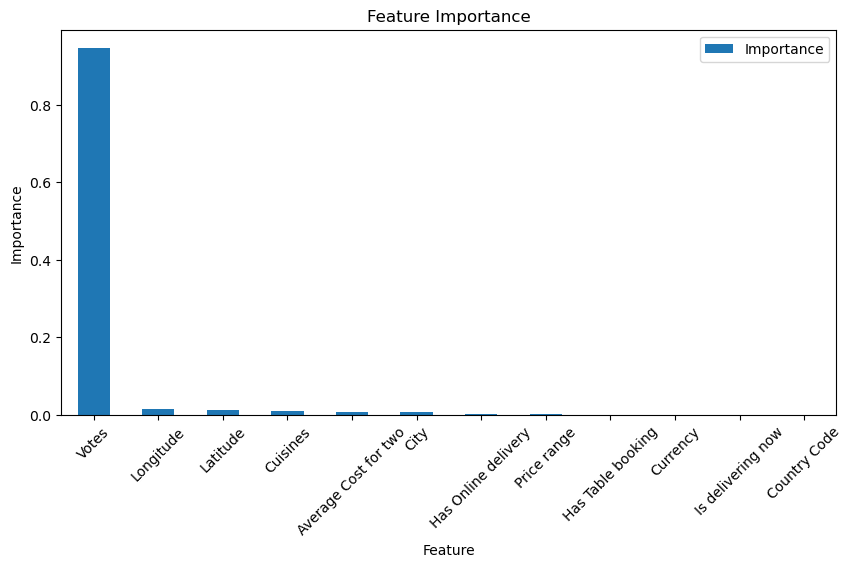

In [34]:
import matplotlib.pyplot as plt 

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

**Step 15 : Conclusion**

A Decision Tree Regressor was developed to predict restaurant aggregate ratings. The model achieved a Mean Squared Error (MSE) of 0.169 and an R² Score
of 0.9253, indicating excellent predictive performance. The feature importance analysis identified the factors that had the greatest influence on 
restaurant ratings.